<a href="https://colab.research.google.com/github/Yanina2105/MD-Lab16_FT/blob/develop/SEMANA_16_DESARROLLO_DE_APLICACIONES_DE_MACHINE_LEARNING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LABORATORIO 16: DESARROLLO DE APLICACIONES DE MACHINE LEARNING**

Tomando la información disponible en el repositorio UCI Machine Learning
https://archive.ics.uci.edu/ml/datasets/Adult, uniendo los archivos **‘adult.data’ y ‘adult.test’**, cuya
variable de clasificación tiene las categorías ‘>50K’ y ‘<=50K’, haga lo siguiente:

## **a. Realice el preprocesamiento de la información que incluya la corrección de errores, la imputación de datos faltantes, tratamiento de outliers a nivel univariado y multivariado, transformación de variables y análisis de correlación entras las variables predictoras.**

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
train = pd.read_csv('/content/adult_data.csv', sep=';')
train.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,1
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,1
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,1
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,1
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,1


In [60]:
test = pd.read_csv('/content/adult_test.csv', sep=';')
test.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,1
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,1
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,0
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,0
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,1


In [61]:
df = pd.concat([train, test], ignore_index=True)
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,1
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,1
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,1
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,1
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,1


In [62]:
# Corrección de errores
df = df.replace('?', pd.NA)
df = df.dropna()

In [64]:
# Tratamiento de outliers univariados
def remove_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]
    return df

df = remove_outliers_iqr(df, ['age', 'hours_per_week', 'capital_gain', 'capital_loss'])

In [66]:
# Transformación de variables
df['capital_gain'] = np.log1p(df['capital_gain'])
df['capital_loss'] = np.log1p(df['capital_loss'])

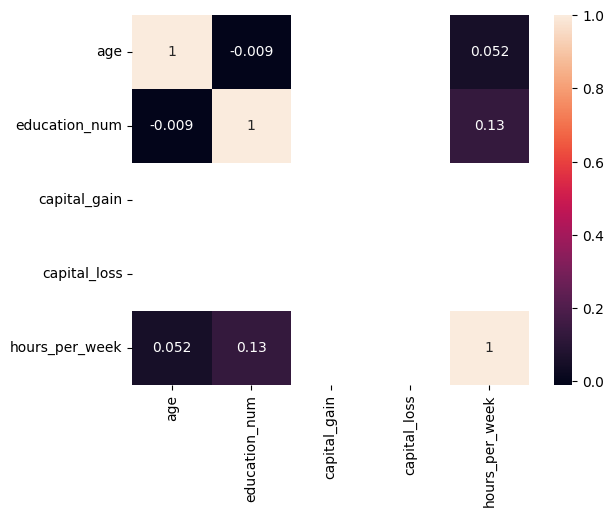

In [67]:
# Análisis de correlación entras las variables predictoras
sns.heatmap(df[['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']].corr(), annot=True)
plt.show()

## **b. Calcule el information value (IV) y seleccione las mejores variables, además, aplique un escalamiento a las variables numéricas y convierta las variables categóricas a dummies. Separe los datos en entrenamiento (80%) y prueba (20%) y realice un balanceo de clases.**

In [73]:
!pip install scorecardpy
import scorecardpy as sc

In [74]:
bins = sc.woebin(df, y='income')

[INFO] creating woe binning ...


/usr/local/lib/python3.11/dist-packages/scorecardpy/woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index()\
/usr/local/lib/python3.11/dist-packages/scorecardpy/woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index()\
/usr/local/lib/python3.11/dist-packages/scorecardpy/woebin.py:446: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binni

In [76]:
iv_list = []

for var, df_bin in bins.items():
    # Total de goods y bads
    total_good = df_bin['good'].sum()
    total_bad = df_bin['bad'].sum()

    # Distribuciones
    df_bin['dist_good'] = df_bin['good'] / total_good
    df_bin['dist_bad'] = df_bin['bad'] / total_bad

    # Cálculo de IV
    iv = (df_bin['dist_good'] - df_bin['dist_bad']) * df_bin['woe']
    iv_list.append({'variable': var, 'total_iv': iv.sum()})

In [77]:
iv_df = pd.DataFrame(iv_list)
iv_sorted = iv_df.sort_values(by='total_iv', ascending=False)

print(iv_sorted)

          variable  total_iv
3           fnlwgt -0.008674
2   native_country -0.075083
0             race -0.082624
4        workclass -0.095282
10  hours_per_week -0.186081
1              sex -0.283783
9    education_num -0.565020
6        education -0.565020
5       occupation -0.620457
11             age -0.881377
8   marital_status -1.415633
7     relationship -1.494333


In [80]:
X = df.drop('income', axis=1)
y = df['income']

In [82]:
from sklearn.preprocessing import StandardScaler

# Separar variables numéricas y categóricas
num_vars = X.select_dtypes(include=['int64', 'float64']).columns
cat_vars = X.select_dtypes(include='object').columns

# Escalar numéricas
scaler = StandardScaler()
X[num_vars] = scaler.fit_transform(X[num_vars])

# Codificar categóricas a dummies
X = pd.get_dummies(X, columns=cat_vars, drop_first=True)

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

In [84]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

## **c. Entrene los modelos k-NN, SVM, regresión logística, árbol de clasificación y Random Forest utilizando hiperparámetros estándar, búsqueda en cuadrícula y búsqueda aleatoria para poder encontrar el modelo de clasificación con mejor desempeño. Luego, obtenga el mejor accuracy junto con los hiperparámetros óptimos para dicho modelo.**

In [85]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score

In [86]:
def evaluar_modelo(nombre, modelo, param_grid, X_train, y_train, X_test, y_test):
    print(f"\n Evaluando modelo: {nombre}")

    # Modelo base
    modelo_base = modelo
    modelo_base.fit(X_train, y_train)
    y_pred_base = modelo_base.predict(X_test)
    acc_base = accuracy_score(y_test, y_pred_base)
    print(f" Accuracy modelo base: {acc_base:.4f}")

    # Grid Search
    grid = GridSearchCV(modelo, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    acc_grid = accuracy_score(y_test, grid.predict(X_test))
    print(f" Accuracy GridSearchCV: {acc_grid:.4f}")
    print(f" Hiperparámetros óptimos (grid): {grid.best_params_}")

    # Random Search
    random = RandomizedSearchCV(modelo, param_distributions=param_grid, n_iter=10,
                                cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
    random.fit(X_train, y_train)
    acc_random = accuracy_score(y_test, random.predict(X_test))
    print(f" Accuracy RandomSearchCV: {acc_random:.4f}")
    print(f" Hiperparámetros óptimos (random): {random.best_params_}")

    # Mejor resultado
    acc_max = max(acc_base, acc_grid, acc_random)
    if acc_max == acc_base:
        best_type = "Modelo base"
    elif acc_max == acc_grid:
        best_type = "GridSearchCV"
    else:
        best_type = "RandomSearchCV"

    print(f" Mejor Accuracy: {acc_max:.4f} ({best_type})\n")

In [87]:
# k-NN
param_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

In [88]:
# SVM
param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

In [89]:
# Regresión logística
param_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

In [90]:
# Árbol
param_dt = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

In [91]:
# Random Forest
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5]
}

In [ ]:
evaluar_modelo("k-NN", KNeighborsClassifier(), param_knn, X_train_bal, y_train_bal, X_test, y_test)
evaluar_modelo("SVM", SVC(), param_svm, X_train_bal, y_train_bal, X_test, y_test)
evaluar_modelo("Regresión Logística", LogisticRegression(max_iter=1000), param_lr, X_train_bal, y_train_bal, X_test, y_test)
evaluar_modelo("Árbol de Clasificación", DecisionTreeClassifier(), param_dt, X_train_bal, y_train_bal, X_test, y_test)
evaluar_modelo("Random Forest", RandomForestClassifier(), param_rf, X_train_bal, y_train_bal, X_test, y_test)


 Evaluando modelo: k-NN
 Accuracy modelo base: 0.7747
 Accuracy GridSearchCV: 0.7816
 Hiperparámetros óptimos (grid): {'n_neighbors': 3, 'weights': 'distance'}
 Accuracy RandomSearchCV: 0.7816
 Hiperparámetros óptimos (random): {'weights': 'distance', 'n_neighbors': 3}
 Mejor Accuracy: 0.7816 (GridSearchCV)


 Evaluando modelo: SVM
 Accuracy modelo base: 0.7940
